In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip install keras-cv -q

In [4]:
import tensorflow as tf
tf.__version__

E0000 00:00:1755606199.847820  104654 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755606199.855664  104654 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.18.0'

In [5]:
import keras
tf.__version__

'2.18.0'

In [6]:
import cv2
import math
import time
import shutil 
import random
import numpy as np
import pandas as pd 
from glob import glob
import matplotlib.pyplot as plt
import albumentations as A
from functools import partial

In [7]:
import keras_cv
from keras import ops
from keras import layers
import tensorflow_datasets as tfds

tfds.disable_progress_bar()
keras.utils.set_random_seed(42)

In [8]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [9]:
keras.saving.get_custom_objects().clear()
tf.keras.backend.clear_session() ## to clear other sessions in the environment
# tf.config.optimizer.set_jit(True) ## enabling XLA
# policy = tf.keras.mixed_precision.Policy('mixed_float16')
# tf.keras.mixed_precision.set_global_policy(policy)

In [10]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [11]:
!nvidia-smi

Tue Aug 19 17:53:24 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.03              Driver Version: 575.64.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA TITAN Xp                Off |   00000000:03:00.0  On |                  N/A |
| 24%   43C    P8             18W /  250W |     326MiB /  12288MiB |     29%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Variables

In [12]:
# transform_list = ['AutoContrast', 'BoxBlur', 'CLAHE', 'ChannelShuffle', 'ChromaticAberration', 'CoarseDropout', 
#                   'ColorJitter', 'Defocus', 'Dilation', 'ElasticTransform', 'Emboss', 'Equalize', 'EqualizeYUV', 
#                   'Erosion', 'Frost', 'Gamma', 'GaussNoise', 'GaussianBlur', 'GlassBlur', 'HorizontalFlip', 
#                   'HueSaturationValue', 'Invert', 'JPEGCompression', 'MedianBlur', 'MotionBlur', 'OpticalDistortion', 
#                   'Original', 'Perspective', 'Posterize', 'RGBShift', 'RandomBrightnessContrast', 'RandomFog', 
#                   'RandomGravel', 'RandomGridShuffle', 'RandomRain', 'RandomShadow', 'RandomSnow', 'RandomSunFlare', 
#                   'RandomToneCurve', 'Rotate', 'SaltandPepper', 'Scale', 'Sharpen', 'ShearX', 'ShearY', 'ShiftScaleRotate', 
#                   'Solarize', 'Speckle', 'ToGray', 'ToSepia', 'Translate', 'VerticalFlip', 'Vignette', 'ZoomBlur']

In [13]:
transform_list = ['Original']

In [14]:
print(len(transform_list))

1


In [15]:
threshold = 0.50
end = '_ISIC2019_classification_Sel_Aug_Th_'+str(threshold)
destination='Results/classification2/2.ISIC2019/Fold1/'

In [16]:
tempfolder="temp_ISIC2019_sel_aug_1"
isExist = os.path.exists(tempfolder)
if not isExist:
    os.makedirs(tempfolder)

data_root="Datasets/2.ISIC2019/classification/fold1/"
output_path="./"+tempfolder+"/"

train_dir=data_root+"train/"
test_dir=data_root+"test/"

In [17]:
num_classes = len(os.listdir(train_dir))
num_train_images = len(glob(train_dir + '/*/*'))
num_test_images = len(glob(test_dir + '/*/*'))

print("num_classes : ", num_classes)
print("num_train_images : ", num_train_images)
print("num_test_images : ", num_test_images)

num_classes :  8
num_train_images :  17064
num_test_images :  4261


In [18]:
EPOCHS=40
IMG_SIZE=224
BATCH_SIZE=64
LEARNING_RATE=0.0001
dropout_rate=0.3
BUFFER_SIZE=num_train_images
AUTOTUNE = tf.data.AUTOTUNE

In [19]:
# ham10000 = 512
# padufes20 = 464
# derm7pt = 208
# hiba = 192
# ph2 = 40
# mednode = 144

In [20]:
classes=sorted(os.listdir(train_dir))
print(classes)

['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


In [21]:
def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")    
    # image = tf.image.decode_png(image, channels=3)
    # image = tf.image.decode_bmp(image, channels=3)
    # image = tf.image.resize(image, (IMG_SIZE,IMG_SIZE), method="area")
    return image, label

# RandAugment Class

In [22]:
rand_augment = keras_cv.layers.RandAugment(value_range=(0, 255), augmentations_per_image=3, magnitude=0.8)

I0000 00:00:1755606206.380775  104654 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11202 MB memory:  -> device: 0, name: NVIDIA TITAN Xp, pci bus id: 0000:03:00.0, compute capability: 6.1


In [23]:
file_names_train = glob(train_dir + '*/*')
random.shuffle(file_names_train)    
lbls_train = [classes.index(name.split('/')[-2]) for name in file_names_train]
train_ds = tf.data.Dataset.from_tensor_slices((file_names_train, lbls_train))
train_ds = train_ds.map(parse_image, num_parallel_calls=AUTOTUNE)
train_ds_randaugment=train_ds.map(lambda x, y: (rand_augment(tf.cast(x, tf.uint8)), y), num_parallel_calls=AUTOTUNE)

In [24]:
file_names_test=glob(test_dir + '*/*')     
lbls_test=[classes.index(name.split('/')[-2]) for name in file_names_test]
test_ds=tf.data.Dataset.from_tensor_slices((file_names_test, lbls_test))
test_ds=test_ds.map(parse_image, num_parallel_calls=AUTOTUNE)

In [25]:
tr_lb=np.array(lbls_train)
tr_lb_unique=np.unique(tr_lb)
print((np.unique(tr_lb, return_counts=True)))

(array([0, 1, 2, 3, 4, 5, 6, 7]), array([ 484, 2123, 1639,  115, 2972, 9270,  338,  123]))


In [26]:
from sklearn.utils import compute_class_weight
#formula: n_samples / (n_classes * np.bincount(y))
classWeight=compute_class_weight(class_weight="balanced",classes=tr_lb_unique,y=tr_lb)
classWeight=np.round(classWeight,4)
classWeight_dict = dict(zip(tr_lb_unique, classWeight))
print("classWeight : ",classWeight_dict)

classWeight :  {np.int64(0): np.float64(4.407), np.int64(1): np.float64(1.0047), np.int64(2): np.float64(1.3014), np.int64(3): np.float64(18.5478), np.int64(4): np.float64(0.7177), np.int64(5): np.float64(0.2301), np.int64(6): np.float64(6.3107), np.int64(7): np.float64(17.3415)}


# Albumentations

In [27]:
# class AutoContrast(A.ImageOnlyTransform):
#     def __init__(self, cutoff=3, always_apply=False, p=1.0):
#         super().__init__(always_apply, p)
#         self.cutoff = cutoff

#     def autocontrast_channel(self, channel):
#         low_val = np.percentile(channel, self.cutoff)
#         high_val = np.percentile(channel, 100 - self.cutoff)

#         if high_val > low_val:
#             # Scale pixel values to [0, 255]
#             scaled = (channel - low_val) * (255.0 / (high_val - low_val))
#             return np.clip(scaled, 0, 255).astype(np.uint8)
#         else:
#             return channel.copy()

#     def apply(self, img, **params):
#         channels = cv2.split(img)
#         auto_channels = [self.autocontrast_channel(ch).astype(np.uint8) for ch in channels]
#         h, w = img.shape[:2]
#         auto_channels = [cv2.resize(ch, (w, h)) for ch in auto_channels]
#         return cv2.merge(auto_channels)

# # ===================================

# class SaltAndPepperNoise(A.ImageOnlyTransform):
#     def __init__(self, salt_prob=0.01, pepper_prob=0.01, always_apply=False, p=1.0):
#         super(SaltAndPepperNoise, self).__init__(always_apply, p)
#         self.salt_prob = salt_prob
#         self.pepper_prob = pepper_prob

#     def apply(self,img,**params):
#         noisy_img = img.copy()
#         salt_mask = np.random.rand(*img.shape[:2]) < self.salt_prob
#         noisy_img[salt_mask] = 255
#         pepper_mask = np.random.rand(*img.shape[:2]) < self.pepper_prob
#         noisy_img[pepper_mask] = 0
#         return noisy_img

# # ===================================

# class SpeckleNoise(A.ImageOnlyTransform):
#     def __init__(self, noise_prob=0.1, always_apply=False, p=1.0):
#         super(SpeckleNoise, self).__init__(always_apply,p)
#         self.noise_prob = noise_prob

#     def apply(self, img, **params):
#         noise = np.random.normal(0, self.noise_prob, img.shape)
#         noisy_img = img + img * noise
#         noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
#         return noisy_img

# # ===================================

# class EmbossEffect(A.ImageOnlyTransform):
#     def __init__(self, emboss_strength=1.0, always_apply=False, p=1.0):
#         super(EmbossEffect, self).__init__(always_apply, p)
#         self.emboss_strength = emboss_strength

#     def apply(self, img, **params):
#         kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]],dtype=np.float32)
#         embossed_img = cv2.filter2D(img, -1, kernel * self.emboss_strength)
#         embossed_img = np.clip(embossed_img, 0, 255).astype(np.uint8)
#         return embossed_img

# # ===================================

# class EqualizeYUV(A.ImageOnlyTransform):
#     def __init__(self, always_apply=False, p=1.0):
#         super().__init__(always_apply, p)

#     def apply(self, image, **kwargs):
#         yuv_image = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
#         y_channel = yuv_image[:, :, 0].astype(np.uint8)
#         yuv_image[:, :, 0] = cv2.equalizeHist(y_channel)
#         return cv2.cvtColor(yuv_image, cv2.COLOR_YUV2BGR)

# # ===================================

# class VignetteEffect(A.ImageOnlyTransform):
#     def __init__(self, intensity=0.6, always_apply=False, p=1.0):
#         super().__init__(always_apply, p)
#         self.intensity = intensity

#     def apply(self, img, **params):
#         rows, cols = img.shape[:2]
#         X_resultant_kernel = cv2.getGaussianKernel(cols, cols * self.intensity)
#         Y_resultant_kernel = cv2.getGaussianKernel(rows, rows * self.intensity)
#         resultant_kernel = Y_resultant_kernel * X_resultant_kernel.T
#         # mask = 255 * resultant_kernel / np.linalg.norm(resultant_kernel)
#         mask = resultant_kernel / resultant_kernel.max()  # Normalize to range [0, 1]
#         output = img.copy()
#         for i in range(3):  # Loop over color channels
#             output[:, :, i] = np.clip(output[:, :, i] * mask, 0, 255)
#         return output.astype(np.uint8)


# # ===================================

# class FrostEffect(A.ImageOnlyTransform):
#     def __init__(self, frost_texture_path="frost/4.jpg", alpha=0.5, always_apply=False, p=1.0):
#         super().__init__(always_apply, p)
#         self.frost_texture_path = frost_texture_path
#         self.alpha = alpha

#     def apply(self, img, **params):
#         frost_texture = cv2.imread(self.frost_texture_path)
#         if frost_texture is None:
#             raise ValueError(f"Frost texture image at path {self.frost_texture_path} could not be loaded.")

#         frost_texture = cv2.cvtColor(frost_texture, cv2.COLOR_BGR2RGB)
#         frost_texture = cv2.resize(frost_texture, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)
        
#         if frost_texture.dtype != img.dtype:
#             frost_texture = frost_texture.astype(img.dtype)
        
#         frosted_image = cv2.addWeighted(img, 1 - self.alpha, frost_texture, self.alpha, 0)
#         frosted_image = cv2.cvtColor(frosted_image, cv2.COLOR_RGB2BGR)
#         return frosted_image

In [28]:
# def augment_train_data(train_ds, transform_list):
#     transform_mapping = {
#         'AutoContrast': AutoContrast(cutoff=3, p=1.0), 
#         'BoxBlur': A.Blur(p=1.0), 
#         'CLAHE': A.CLAHE(clip_limit=2.0, p=1.0),
#         'ChannelShuffle': A.ChannelShuffle(p=1.0),
#         'ChromaticAberration': A.ChromaticAberration(mode='random', p=1.0),
#         'CoarseDropout': A.CoarseDropout(num_holes_range=(20,40), hole_height_range=(20,40), hole_width_range=(20,40), p=1.0), 
#         'ColorJitter': A.ColorJitter(brightness=(0.8,1.2), contrast=(0.8,1.2), saturation=(0.8,1.2), hue=(-0.5,0.5), p=1.0), 
#         'Defocus': A.Defocus(radius=(3,5), p=1.0),
#         'Dilation': A.Morphological(scale=(3,5), operation='dilation', p=1.0),
#         'ElasticTransform': A.ElasticTransform(p=1.0),
#         'Emboss': EmbossEffect(emboss_strength=1.0, p=1.0),
#         'Equalize': A.Equalize(p=1.0),
#         'EqualizeYUV': EqualizeYUV(p=1.0),
#         'Erosion': A.Morphological(scale=(3,5), operation='erosion', p=1.0),
#         'Frost': FrostEffect(frost_texture_path="frost/4.jpg", alpha=0.5, p=1.0),
#         'Gamma': A.RandomGamma(p=1.0),
#         'GaussNoise': A.GaussNoise(p=1.0),
#         'GaussianBlur': A.GaussianBlur(p=1.0),
#         'GlassBlur': A.GlassBlur(p=1.0),
#         'HorizontalFlip': A.HorizontalFlip(p=1.0),
#         'HueSaturationValue': A.HueSaturationValue(p=1.0),
#         'Invert': A.InvertImg(p=1.0),
#         'JPEGCompression': A.ImageCompression(quality_lower=10, quality_upper=30, p=1.0),
#         'MedianBlur': A.MedianBlur(p=1.0),
#         'MotionBlur': A.MotionBlur(p=1.0),
#         'OpticalDistortion': A.OpticalDistortion(distort_limit=0.5, p=1.0),
#         'Original': A.NoOp(p=1.0), # original
#         'Perspective': A.Perspective(scale=0.2, p=1.0),
#         'Posterize': A.Posterize(p=1.0), 
#         'RGBShift': A.RGBShift(p=1.0),
#         'RandomBrightnessContrast': A.RandomBrightnessContrast(p=1.0),
#         'RandomFog': A.RandomFog(fog_coef_lower=0.5, fog_coef_upper=0.8, alpha_coef=0.2, p=1.0),
#         'RandomGravel': A.RandomGravel(gravel_roi=(0,0,1,1), number_of_patches=40, p=1.0),
#         'RandomGridShuffle': A.RandomGridShuffle(p=1.0),
#         'RandomRain': A.RandomRain(brightness_coefficient=0.9, drop_width=1, blur_value=3, p=1.0), 
#         'RandomShadow': A.RandomShadow(num_shadows_lower=2, num_shadows_upper=3, shadow_dimension=5, shadow_roi=(0,0,1,1), p=1.0), 
#         'RandomSnow': A.RandomSnow(brightness_coeff=2, snow_point_lower=0.4, snow_point_upper=0.7, p=1.0),
#         'RandomSunFlare': A.RandomSunFlare(flare_roi=(0,0,1,1), src_radius=150, angle_lower=0.8, p=1.0),
#         'RandomToneCurve': A.RandomToneCurve(scale=0.2, p=1.0), 
#         'Rotate': A.augmentations.geometric.transforms.Affine(rotate=(-45,45), mode=2, p=1.0),
#         'SaltandPepper': SaltAndPepperNoise(salt_prob=0.01, pepper_prob=0.01, p=1.0),
#         'Scale': A.augmentations.geometric.transforms.Affine(scale=(0.7,1.3), mode=2, p=1.0),
#         'Sharpen': A.Sharpen(p=1.0),
#         'ShearX': A.augmentations.geometric.transforms.Affine(shear={'x':(-20,20)}, mode=2, p=1.0),
#         'ShearY': A.augmentations.geometric.transforms.Affine(shear={'y':(-20,20)}, mode=2, p=1.0),
#         'ShiftScaleRotate': A.ShiftScaleRotate(p=1.0),
#         'Solarize': A.Solarize(p=1.0),
#         'Speckle': SpeckleNoise(noise_prob=0.1, p=1.0),
#         'ToGray': A.ToGray(method='weighted_average', p=1.0),         
#         'ToSepia': A.ToSepia(p=1.0),
#         'Translate': A.augmentations.geometric.transforms.Affine(translate_percent=(-0.1,0.1), mode=2, p=1.0),
#         'VerticalFlip': A.VerticalFlip(p=1.0),
#         'Vignette': VignetteEffect(intensity=0.6, p=1.0),
#         'ZoomBlur': A.ZoomBlur(p=1.0),  
#     }
    
#     def aug_fn(image):
#         selected_transform_name = random.choice(transform_list)
#         selected_transform = transform_mapping[selected_transform_name]
#         # image = tf.cast(image, tf.uint8).numpy()

#         if selected_transform:
#             data = {"image": image}
#             augmented = selected_transform(**data)
#             aug_img = augmented["image"]
#         else:
#             aug_img = image

#         aug_img = tf.cast(aug_img, tf.float32)
#         return tf.image.resize(aug_img, size=[IMG_SIZE, IMG_SIZE], method="area")

#     def process_data(image, label):
#         aug_img = tf.numpy_function(func=aug_fn, inp=[image], Tout=tf.float32)
#         return aug_img, label

#     def set_shapes(img, label, img_shape=(IMG_SIZE, IMG_SIZE, 3)):
#         img.set_shape(img_shape)
#         label.set_shape([])
#         return img, label

#     ds_alb = train_ds.map(partial(process_data), num_parallel_calls=AUTOTUNE)
#     ds_alb = ds_alb.map(set_shapes, num_parallel_calls=AUTOTUNE)
#     ds_alb = ds_alb.batch(BATCH_SIZE).prefetch(AUTOTUNE)
#     return ds_alb

In [29]:
def augment_test_data(test_ds):
    transforms = A.OneOf([A.NoOp()],p=0.1)
    
    def aug_fn(image):
        data = {"image":image}
        aug_data = transforms(**data)
        aug_img = aug_data["image"]
        aug_img = tf.cast(aug_img, tf.float32)
        return tf.image.resize(aug_img, size=[IMG_SIZE, IMG_SIZE], method="area")

    def process_data(image, label):
        aug_img = tf.numpy_function(func=aug_fn, inp=[image], Tout=tf.float32)
        return aug_img, label
    
    def set_shapes(img, label, img_shape=(IMG_SIZE, IMG_SIZE,3)):
        img.set_shape(img_shape)
        label.set_shape([])
        return img, label
    
    ds_alb = test_ds.map(partial(process_data), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    ds_alb = ds_alb.map(set_shapes, num_parallel_calls=AUTOTUNE)
    ds_alb = ds_alb.batch(BATCH_SIZE)
    return ds_alb

In [30]:
train_alb = augment_test_data(train_ds_randaugment)
test_alb = augment_test_data(test_ds)

In [31]:
def onehot(image,label):
    return image,tf.one_hot(label,num_classes)

In [32]:
def optimize_data(train_alb, test_alb):
    def configure_for_train(ds):
        ds = ds.unbatch()
        ds = ds.shuffle(buffer_size=BUFFER_SIZE)
        ds = ds.map(onehot, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.prefetch(buffer_size=AUTOTUNE)
        return ds
    
    def configure_for_test(ds):
        ds = ds.map(onehot, num_parallel_calls=AUTOTUNE)
        ds = ds.prefetch(buffer_size=AUTOTUNE)
        return ds

    train_ds = configure_for_train(train_alb)
    test_ds = configure_for_test(test_alb)
    
    return train_ds, test_ds

In [33]:
train_dataset, test_dataset = optimize_data(train_alb, test_alb)

In [34]:
def view_image(ds):
    image, label = next(iter(ds)) # extract 1 batch from the dataset
    image = image.numpy()
    label = label.numpy()
    fig = plt.figure(figsize=(14, 5))
    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    fig.tight_layout()
    for i in range(image.shape[0]):        
        ax = fig.add_subplot(int(BATCH_SIZE/16)+1, 16, i+1, xticks=[], yticks=[])
        ax.imshow((image[i]).astype(np.uint8))

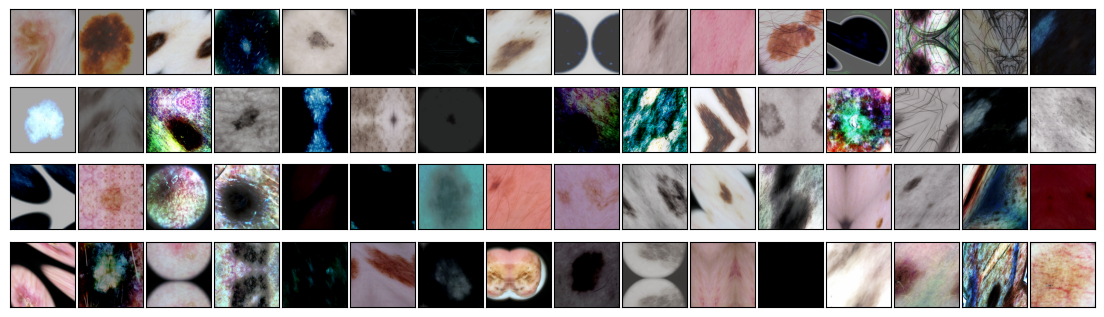

In [35]:
view_image(train_dataset)

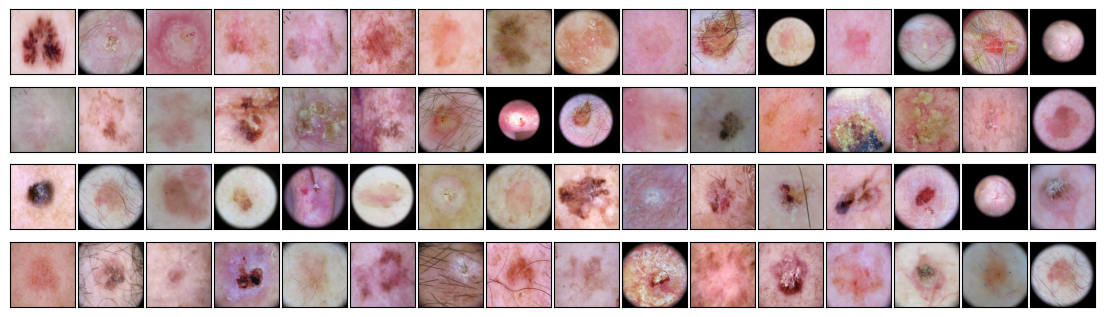

In [36]:
view_image(test_dataset)

# Prepare Model

In [37]:
@keras.saving.register_keras_serializable('SpatialAttention')
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_out = tf.keras.backend.mean(inputs, axis=-1, keepdims=True)
        max_out = tf.keras.backend.max(inputs, axis=-1, keepdims=True)
        concat = tf.keras.backend.concatenate([avg_out, max_out], axis=-1)
        attention_weights = self.conv(concat)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

In [38]:
base_model=tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable=True

x = SpatialAttention()(base_model.output)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout1")(x)
x = tf.keras.layers.Dense(512, activation="silu", name="pred1")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout2")(x)
x = tf.keras.layers.Dense(128, activation="silu", name="pred2")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout3")(x)
output = tf.keras.layers.Dense(num_classes, activation="softmax", name="pred3")(x) 
model = tf.keras.Model(base_model.input, output, name="EfficientNetB0")
# model = tf.keras.models.load_model(weights, custom_objects={'SpatialAttention': SpatialAttention})

In [39]:
# till=model.layers.index(model.get_layer('block5a_expand_conv'))+1    
# for layer in model.layers[:till]:
#     layer.trainable=False
# for layer in model.layers[till:]:
#     layer.trainable=True
    # if isinstance(layer, tf.keras.layers.BatchNormalization):
    #     layer.trainable = False

In [40]:
# i=1
# j=len(model.layers)
# for x in model.layers:
#     print(i, j, x.name, x.output.shape, x.trainable)
#     i=i+1
#     j=j-1

# Model Information

In [41]:
trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]))
non_trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]))
total_count = trainable_count + non_trainable_count

print('Total params: {:,}'.format(total_count))
print('Trainable params: {:,}'.format(trainable_count))
print('Non-trainable params: {:,}'.format(non_trainable_count))

Total params: 4,779,838
Trainable params: 4,733,975
Non-trainable params: 45,863


In [42]:
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

def get_flops(model):
  forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])
  graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
  flops = graph_info.total_float_ops
  return flops

In [43]:
flops = get_flops(model)
macs = flops / 2


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

In [44]:
print(macs/10 ** 9)

0.401186798
lock6a_expand_bn_1/batchnorm/mul (672/672 flops)
  block6a_expand_bn_1/batchnorm/mul_2 (672/672 flops)
  block6a_expand_bn_1/batchnorm/sub (672/672 flops)
  block6a_se_expand_1/BiasAdd (672/672 flops)
  block7a_project_bn_1/batchnorm/Rsqrt (640/640 flops)
  batch_normalization_1_2/batchnorm/add (512/512 flops)
  batch_normalization_1_2/batchnorm/add_1 (512/512 flops)
  batch_normalization_1_2/batchnorm/mul (512/512 flops)
  batch_normalization_1_2/batchnorm/mul_1 (512/512 flops)
  batch_normalization_1_2/batchnorm/mul_2 (512/512 flops)
  batch_normalization_1_2/batchnorm/sub (512/512 flops)
  block1a_se_expand_1/convolution (512/512 flops)
  block1a_se_reduce_1/convolution (512/512 flops)
  pred1_1/BiasAdd (512/512 flops)
  pred1_1/mul (512/512 flops)
  pred1_1/mul_1 (512/512 flops)
  block3b_bn_1/batchnorm/Rsqrt (480/480 flops)
  block3b_expand_bn_1/batchnorm/Rsqrt (480/480 flops)
  block4a_bn_1/batchnorm/Rsqrt (480/480 flops)
  block4a_expand_bn_1/batchnorm/Rsqrt (480/480

In [45]:
print(flops/10 ** 9)

)
  block4a_project_bn_1/batchnorm/Rsqrt (160/160 flops)
  block4b_project_bn_1/batchnorm/Rsqrt (160/160 flops)
  block4c_project_bn_1/batchnorm/Rsqrt (160/160 flops)
  block2b_bn_1/batchnorm/add (144/144 flops)
  block2b_bn_1/batchnorm/mul (144/144 flops)
  block2b_bn_1/batchnorm/mul_2 (144/144 flops)
  block2b_bn_1/batchnorm/sub (144/144 flops)
  block2b_expand_bn_1/batchnorm/add (144/144 flops)
  block2b_expand_bn_1/batchnorm/mul (144/144 flops)
  block2b_expand_bn_1/batchnorm/mul_2 (144/144 flops)
  block2b_expand_bn_1/batchnorm/sub (144/144 flops)
  block2b_se_expand_1/BiasAdd (144/144 flops)
  block3a_bn_1/batchnorm/add (144/144 flops)
  block3a_bn_1/batchnorm/mul (144/144 flops)
  block3a_bn_1/batchnorm/mul_2 (144/144 flops)
  block3a_bn_1/batchnorm/sub (144/144 flops)
  block3a_expand_bn_1/batchnorm/add (144/144 flops)
  block3a_expand_bn_1/batchnorm/mul (144/144 flops)
  block3a_expand_bn_1/batchnorm/mul_2 (144/144 flops)
  block3a_expand_bn_1/batchnorm/sub (144/144 flops)
  b

# Train Model

In [46]:
regularizer=tf.keras.regularizers.l2(0.00001)
for layer in model.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
            setattr(layer, attr, regularizer)

In [47]:
optimizer_fn = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, clipnorm=2.0)  
metrics = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=5, label_smoothing=0.05)
model.compile(optimizer = optimizer_fn, loss = loss_fn, metrics = metrics)

In [48]:
def warmup_gpu(model, input_shape, dtype=tf.float32, steps=3):
    dummy_input = tf.random.normal([1, *input_shape], dtype=dtype)

    for i in range(steps):
        _ = model(dummy_input, training=False)
    print(f"[Warmup] GPU warmed up with {steps} dummy passes.")

# Example usage:
warmup_gpu(model, input_shape=(224, 224, 3))

I0000 00:00:1755606529.466798  104654 cuda_dnn.cc:529] Loaded cuDNN version 90800


[Warmup] GPU warmed up with 3 dummy passes.


In [49]:
ModelCheckPoint=tf.keras.callbacks.ModelCheckpoint(
    filepath=output_path+'EfficientNetB0-{epoch:03d}-{val_accuracy:.4f}.weights.h5',
    monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=True)

In [50]:
def convert(seconds):
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60     
    return "%d:%02d:%02d" % (hour, minutes, seconds)

In [51]:
%%time
t1=time.time()
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    class_weight=classWeight_dict,
    validation_data=test_dataset,
    callbacks=[ModelCheckPoint] 
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ",convert(time_taken)," hh:mm:ss")

Epoch 1/40


I0000 00:00:1755606852.743183  104805 service.cc:148] XLA service 0x7003780020f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755606852.743276  104805 service.cc:156]   StreamExecutor device (0): NVIDIA TITAN Xp, Compute Capability 6.1
E0000 00:00:1755606870.905015  104805 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755606871.052251  104805 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755606871.622472  104805 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755606871.775535  104805 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accur

    266/Unknown 422s 181ms/step - accuracy: 0.1505 - loss: 0.5350

E0000 00:00:1755606967.648679  104803 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755606967.792842  104803 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755606968.321652  104803 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755606968.474611  104803 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755606968.789642  104803 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

    267/Unknown 469s 359ms/step - accuracy: 0.1506 - loss: 0.5348
Epoch 1: val_accuracy improved from -inf to 0.21802, saving model to ./temp_ISIC2019_sel_aug_1/EfficientNetB0-001-0.2180.weights.h5
267/267 ━━━━━━━━━━━━━━━━━━━━ 524s 565ms/step - accuracy: 0.1506 - loss: 0.5347 - val_accuracy: 0.2180 - val_loss: 0.2755
Epoch 2/40
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.2001 - loss: 0.4179
Epoch 2: val_accuracy improved from 0.21802 to 0.35977, saving model to ./temp_ISIC2019_sel_aug_1/EfficientNetB0-002-0.3598.weights.h5
267/267 ━━━━━━━━━━━━━━━━━━━━ 341s 244ms/step - accuracy: 0.2001 - loss: 0.4178 - val_accuracy: 0.3598 - val_loss: 0.2683
Epoch 3/40
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.2215 - loss: 0.3235
Epoch 3: val_accuracy improved from 0.35977 to 0.42643, saving model to ./temp_ISIC2019_sel_aug_1/EfficientNetB0-003-0.4264.weights.h5
267/267 ━━━━━━━━━━━━━━━━━━━━ 343s 243ms/step - accuracy: 0.2215 - loss: 0.3236 - val_accuracy: 0.4264 - val_loss: 

In [52]:
for x in sorted(os.listdir(output_path))[:-3]:
    os.remove(output_path+x)

In [53]:
model.load_weights(output_path+sorted(os.listdir(output_path))[-1]) 

In [54]:
test_loss, test_accuracy_by_evaluate = model.evaluate(test_dataset)

67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 228ms/step - accuracy: 0.7102 - loss: 0.0980


In [55]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [56]:
Hist = {'hist' : history.history} 
df = pd.DataFrame.from_dict(Hist)  
df.to_csv(output_path+'Hist.csv', index = True, header=True)  

In [57]:
num_epoch = len(history.history['loss'])
executed_epoch_count = len(history.history['loss'])

In [58]:
savedfilename="epochs_{}".format(executed_epoch_count)+"_test_acc_{}".format(test_accuracy_by_evaluate_rounded)

In [59]:
name=output_path+"{}".format(savedfilename)+".keras"
model.save(name)

In [60]:
name_weights=output_path+"{}".format(savedfilename)+".weights.h5"
model.save_weights(name_weights)

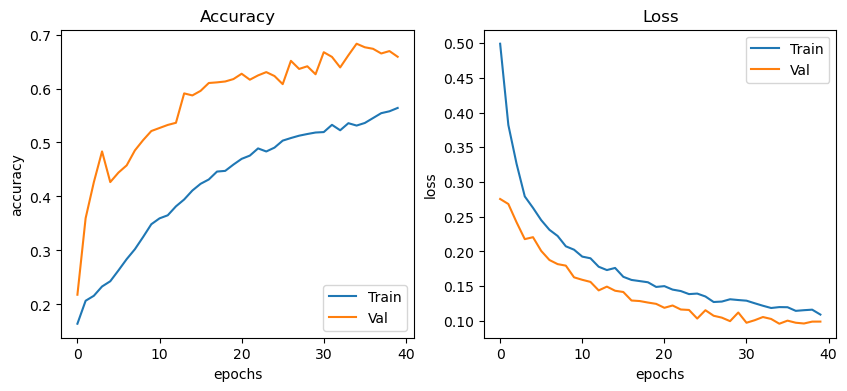

In [61]:
figpath=output_path+"{}".format(savedfilename)+".pdf"
fig = plt.figure(figsize=(10,4))
epochs_range = range(len(history.history['loss']))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Val')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Val')
plt.legend(loc='upper right')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
fig.savefig(figpath, format='pdf', bbox_inches='tight')

# Predictions

In [62]:
# predictions=model.predict(test_dataset)
# y_pred = np.argmax(predictions, axis=1)
# y_true = np.concatenate([y for x, y in test_dataset], axis=0)
# y_prob = predictions

# same = 0
# total = len(y_true)

# for i in range(total):
#     if y_true[i] == y_pred[i]:
#         same=same+1
        
# test_acc = same/total*100
# res='{:.2f}'.format(test_acc)
# print(same)
# print(total)
# print(res)

In [63]:
%%time
predi=model.predict(test_dataset)
y_p = np.argmax(predi, axis=1)
y_t = np.concatenate([y for x, y in test_dataset], axis=0)
y_tt = np.argmax(y_t, axis=1)
y_pr = predi

same = 0
total = len(y_tt)

for i in range(total):
    if y_tt[i] == y_p[i]:
        same=same+1
        
test_acc = same/total*100
res='{:.2f}'.format(test_acc)
print(same)
print(total)
print(res)

67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 220ms/step
2910
4261
68.29
CPU times: user 4min 21s, sys: 16 s, total: 4min 37s
Wall time: 43 s


In [64]:
y_pred = y_p
y_true = y_tt
y_prob = y_pr

In [65]:
%%time
tm = []
correctly_classified = {"y_true":[], "y_pred":[], "y_prob":[], "filename":[], "inference_time":[]}
mis_classified = {"orig":[],"pred":[], "prob":[], "filename":[], "inference_time":[]}
for i in file_names_test:
    image=tf.keras.utils.load_img(i)
    input_arr=tf.keras.utils.img_to_array(image)
    img_resized=tf.image.resize(input_arr, size=(IMG_SIZE, IMG_SIZE))
    input_img=np.array([img_resized])  
    start_time=time.time()  
    predictions=model(input_img, training=False)
    end_time=time.time()
    t=1000*(end_time-start_time)
    tm.append(t)
    pr_fnl = np.argmax(predictions, axis=1)[0]
    lbl=classes.index(i.split('/')[-2])
    
    if lbl == pr_fnl:
        correctly_classified["y_true"].append(lbl)
        correctly_classified["y_pred"].append(pr_fnl)
        correctly_classified["y_prob"].append(predictions)
        correctly_classified["filename"].append(i)
        correctly_classified["inference_time"].append(t)
    else:
        mis_classified["orig"].append(lbl)
        mis_classified["pred"].append(pr_fnl)
        mis_classified["prob"].append(predictions)
        mis_classified["filename"].append(i)
        mis_classified["inference_time"].append(t)

print(len(correctly_classified["y_true"]))
print(len(y_t))
test_acc1 = len(correctly_classified["y_true"])/len(y_t)*100
print('{:.2f}'.format(test_acc1))

2768
4261
64.96
CPU times: user 19min 33s, sys: 2.82 s, total: 19min 36s
Wall time: 19min 35s


In [66]:
# print(f"Average (ms) : {np.mean(tm)}")
# print(f"Std dev (ms) : {np.std(tm)}")
# print(f"Min     (ms) : {np.min(tm)}")
# print(f"Max     (ms) : {np.max(tm)}")

In [67]:
df11 = pd.DataFrame.from_dict(correctly_classified) 
df11.to_csv(output_path+'correctly_classified.csv', index = True, header=True)

df22 = pd.DataFrame.from_dict(mis_classified) 
df22.to_csv(output_path+'mis_classified.csv', index = True, header=True)

In [68]:
# y_pred1=correctly_classified["y_pred"]
# y_true1=correctly_classified["y_true"]  
# y_prob1=correctly_classified["y_prob"]

# y_pred2=mis_classified["pred"]
# y_true2=mis_classified["orig"]  
# y_prob2=mis_classified["prob"]

# y_pred=y_pred1+y_pred2
# y_true=y_true1+y_true2
# y_prob=y_prob1+y_prob2

In [69]:
y_test = tf.keras.utils.to_categorical(y_true)

In [70]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred)
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[  74   15   12    1    5    0   14    0]
 [  47  377   23   18    8    2   48    7]
 [  39   19  223    9   58   40   16    5]
 [   1    1    1   21    1    2    0    1]
 [  35   36   71    9  437  130   17    7]
 [  14   72  150   37  295 1703    5   41]
 [   9   12   10    1    5    0   47    0]
 [   0    0    0    1    0    1    0   28]]


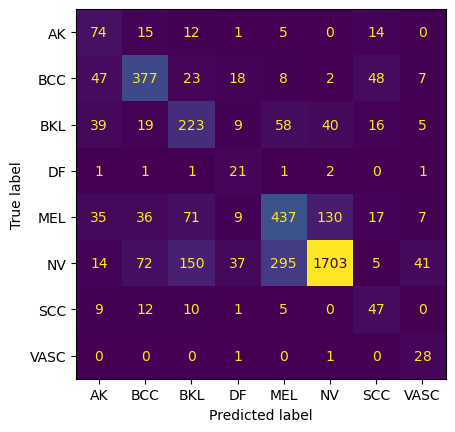

In [71]:
fig_path=output_path+"confusion_matrix.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [72]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred, normalize='all')
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[1.73668153e-02 3.52030040e-03 2.81624032e-03 2.34686693e-04
  1.17343347e-03 0.00000000e+00 3.28561371e-03 0.00000000e+00]
 [1.10302746e-02 8.84768834e-02 5.39779395e-03 4.22436048e-03
  1.87749355e-03 4.69373387e-04 1.12649613e-02 1.64280685e-03]
 [9.15278104e-03 4.45904717e-03 5.23351326e-02 2.11218024e-03
  1.36118282e-02 9.38746773e-03 3.75498709e-03 1.17343347e-03]
 [2.34686693e-04 2.34686693e-04 2.34686693e-04 4.92842056e-03
  2.34686693e-04 4.69373387e-04 0.00000000e+00 2.34686693e-04]
 [8.21403426e-03 8.44872096e-03 1.66627552e-02 2.11218024e-03
  1.02558085e-01 3.05092701e-02 3.98967379e-03 1.64280685e-03]
 [3.28561371e-03 1.68974419e-02 3.52030040e-02 8.68340765e-03
  6.92325745e-02 3.99671439e-01 1.17343347e-03 9.62215442e-03]
 [2.11218024e-03 2.81624032e-03 2.34686693e-03 2.34686693e-04
  1.17343347e-03 0.00000000e+00 1.10302746e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.34686693e-04
  0.00000000e+00 2.34686693e-04 0.00000000e+0

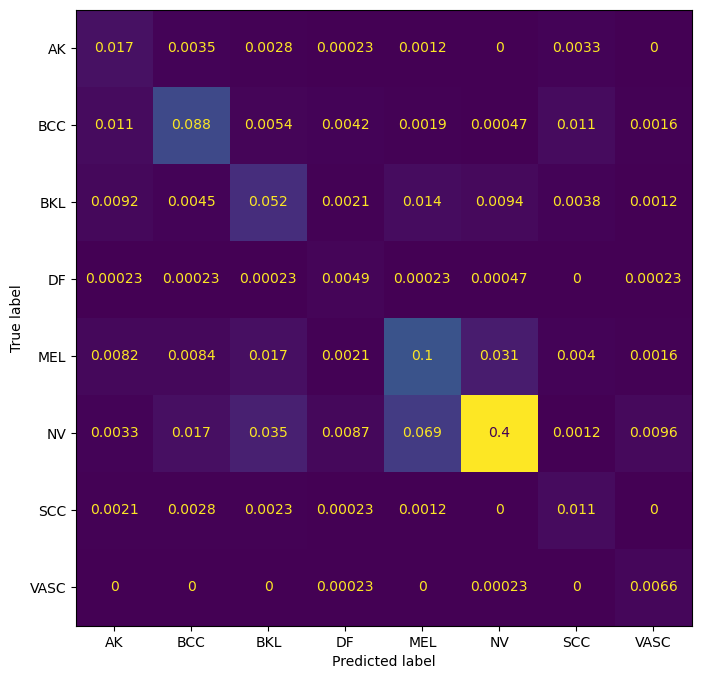

In [73]:
fig_path=output_path+"confusion_matrix1.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.set_figwidth(8)
fig.set_figheight(8)
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [74]:
y_prob = np.array(y_prob)
y_prob_new = y_prob.reshape(y_pr.shape)

In [75]:
from sklearn.metrics import roc_auc_score
targetnames=classes
fpr = {}
tpr = {}
roc_auc = {}
for i in range(num_classes):
    r = roc_auc_score(y_test[:, i], y_prob_new[:, i])
    print("The ROC AUC score of "+targetnames[i]+" is: "+str(r))

The ROC AUC score of AK is: 0.9523306184373378
The ROC AUC score of BCC is: 0.9709385414401522
The ROC AUC score of BKL is: 0.8691188903868564
The ROC AUC score of DF is: 0.9606830684080861
The ROC AUC score of MEL is: 0.8134727229694174
The ROC AUC score of NV is: 0.9113789915652957
The ROC AUC score of SCC is: 0.9453925692853152
The ROC AUC score of VASC is: 0.996336563460175


In [76]:
from sklearn.metrics import roc_curve, auc
fpr = {}
tpr = {}
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob_new[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

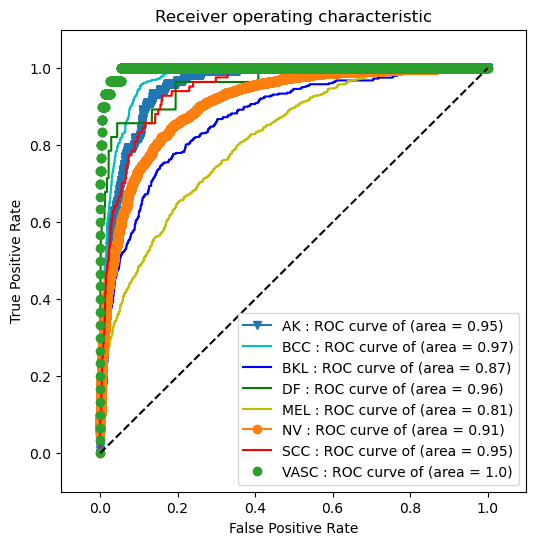

In [77]:
fig_path_roc=output_path+"roc_auc_curve.pdf"
fig = plt.figure(figsize=(6,6))
l0="{}".format(targetnames[0])+" : ROC curve of (area = {}".format(round(roc_auc[0],2))+")"
l1="{}".format(targetnames[1])+" : ROC curve of (area = {}".format(round(roc_auc[1],2))+")"
l2="{}".format(targetnames[2])+" : ROC curve of (area = {}".format(round(roc_auc[2],2))+")"
l3="{}".format(targetnames[3])+" : ROC curve of (area = {}".format(round(roc_auc[3],2))+")"
l4="{}".format(targetnames[4])+" : ROC curve of (area = {}".format(round(roc_auc[4],2))+")"
l5="{}".format(targetnames[5])+" : ROC curve of (area = {}".format(round(roc_auc[5],2))+")"
l6="{}".format(targetnames[6])+" : ROC curve of (area = {}".format(round(roc_auc[6],2))+")"
l7="{}".format(targetnames[7])+" : ROC curve of (area = {}".format(round(roc_auc[7],2))+")"
# l8="{}".format(targetnames[8])+" : ROC curve of (area = {}".format(round(roc_auc[8],2))+")"
plt.plot(fpr[0], tpr[0],'v-',label=l0)
plt.plot(fpr[1], tpr[1],'c' ,label=l1)
plt.plot(fpr[2], tpr[2],'b' ,label=l2)
plt.plot(fpr[3], tpr[3],'g' ,label=l3)
plt.plot(fpr[4], tpr[4],'y' ,label=l4)
plt.plot(fpr[5], tpr[5],'o-',label=l5)
plt.plot(fpr[6], tpr[6],'r' ,label=l6)
plt.plot(fpr[7], tpr[7],'o' ,label=l7)
# plt.plot(fpr[8], tpr[8],'c' ,label=l8)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()
fig.savefig(fig_path_roc, format='pdf', bbox_inches='tight')

In [78]:
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_true, y_pred)
print('Accuracy: {}'.format(accuracy_score))

Accuracy: 0.6829382773996714


In [79]:
from sklearn.metrics import classification_report
classification_report = classification_report(y_true, y_pred, 
    target_names=targetnames, zero_division=0)
print('Classification Report : \n')
print(classification_report)

Classification Report : 

              precision    recall  f1-score   support

          AK       0.34      0.61      0.44       121
         BCC       0.71      0.71      0.71       530
         BKL       0.46      0.55      0.50       409
          DF       0.22      0.75      0.34        28
         MEL       0.54      0.59      0.56       742
          NV       0.91      0.74      0.81      2317
         SCC       0.32      0.56      0.41        84
        VASC       0.31      0.93      0.47        30

    accuracy                           0.68      4261
   macro avg       0.47      0.68      0.53      4261
weighted avg       0.74      0.68      0.70      4261



In [80]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [81]:
micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Precision: {micro_precision}")
print(f"Macro Precision: {macro_precision}")
print(f"Weighted Precision: {weighted_precision}")

Micro Precision: 0.6829382773996714
Macro Precision: 0.4749333116784232
Weighted Precision: 0.7385268743719149


In [82]:
micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Recall: {micro_recall}")
print(f"Macro Recall: {macro_recall}")
print(f"Weighted Recall: {weighted_recall}")

Micro Recall: 0.6829382773996714
Macro Recall: 0.6793664205464396
Weighted Recall: 0.6829382773996714


In [83]:
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro F1: {micro_f1}")
print(f"Macro F1: {macro_f1}")
print(f"Weighted F1: {weighted_f1}")

Micro F1: 0.6829382773996714
Macro F1: 0.5287903848120541
Weighted F1: 0.7014584508069448


In [84]:
from sklearn.metrics import roc_auc_score
micro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="micro")
macro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="macro")
weighted_roc_auc_ovr = roc_auc_score(y_true, y_prob_new, multi_class='ovr',average='weighted')

print(f"Micro-averaged One-vs-Rest ROC AUC score: {micro_roc_auc_ovr}")
print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr}")
print(f"Weighted One-vs-Rest ROC AUC score: {weighted_roc_auc_ovr}")

Micro-averaged One-vs-Rest ROC AUC score: 0.9412640272351441
Macro-averaged One-vs-Rest ROC AUC score: 0.9274564957440794
Weighted One-vs-Rest ROC AUC score: 0.9004372542834354


In [85]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score = balanced_accuracy_score(y_true, y_pred)
print('balanced_accuracy_score : ', balanced_accuracy_score)

balanced_accuracy_score :  0.6793664205464396


In [86]:
from sklearn.metrics import jaccard_score
jaccard_score = jaccard_score(y_true, y_pred, average='weighted')
print('jaccard_score : ', jaccard_score)

jaccard_score :  0.556464899367613


In [87]:
specificity = []
cm = np.array(confusion_matrix(y_true, y_pred))
for i in range(cm.shape[0]):
    tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_i = np.round(specificity_i, 6)
    specificity.append(specificity_i)

print(f'Specificity for each class: {specificity}')
spec_unweighted=np.round(np.average(specificity), 6)
spec_weighted=np.round(np.average(specificity, weights=list(classWeight_dict.values())), 6)
print(spec_unweighted)
print(spec_weighted)

Specificity for each class: [np.float64(0.964976), np.float64(0.958456), np.float64(0.930685), np.float64(0.982046), np.float64(0.894288), np.float64(0.909979), np.float64(0.976059), np.float64(0.985583)]
0.950259
0.977598


In [88]:
from sklearn.metrics import multilabel_confusion_matrix
multilabel_confusion_matrix = multilabel_confusion_matrix(y_true, y_pred)
print('multilabel_confusion_matrix : \n', multilabel_confusion_matrix)

multilabel_confusion_matrix : 
 [[[3995  145]
  [  47   74]]

 [[3576  155]
  [ 153  377]]

 [[3585  267]
  [ 186  223]]

 [[4157   76]
  [   7   21]]

 [[3147  372]
  [ 305  437]]

 [[1769  175]
  [ 614 1703]]

 [[4077  100]
  [  37   47]]

 [[4170   61]
  [   2   28]]]


# Saving All Results

In [89]:
import pandas as pd  
Labels={'File_Name':[],'True_Label':[],'Predicted_Label':[],'Prediction_Probability':[]}

for i in range(len(file_names_test)): 
    Labels['File_Name'].append(file_names_test[i])
    Labels['True_Label'].append(y_true[i])
    Labels['Predicted_Label'].append(y_pred[i])
    Labels['Prediction_Probability'].append(y_prob_new[i])

df = pd.DataFrame.from_dict(Labels) 
df.to_csv(output_path+'Labels.csv', index = False, header=True)

In [90]:
Class_Weights = {'classWeight' : classWeight}
df = pd.DataFrame.from_dict(Class_Weights) 
df.to_csv(output_path+'Class_Weights.csv', index = True, header=True)

In [91]:
Hist = {'hist' : history.history}
df = pd.DataFrame.from_dict(Hist) 
df.to_csv(output_path+'Hist.csv', index = True, header=True)

In [92]:
Hyperparameters = {
    'Number_of_Classes' : num_classes,
    'Number_of_Train_Images' : num_train_images,
    'Number_of_Test_Images' : num_test_images,
    'BATCH_SIZE' : BATCH_SIZE,
    'IMG_SIZE' : IMG_SIZE,
    'LEARNING_RATE' : LEARNING_RATE,
    'EPOCHS' : EPOCHS,
    'Number_of_Epoch_Actually_Executed' : len(history.history['loss']),            
}
df = pd.DataFrame.from_records([Hyperparameters]).transpose()
df.to_csv(output_path+'Hyperparameters.csv', index = True, header=False)

In [93]:
Results_in_Program = {
    'Time_Taken_for_execution_(in_seconds)' : time_taken,
    'Test_Accuracy_by_Model_Evaluate_Method' : test_accuracy_by_evaluate,        
    'Number_of_Correct_Predictions' : same,
    'Number_of_Total_Predictions' : total,
    'Test_Accuracy_by_Manual_Matching' : test_acc,
    'Test_Accuracy_Result_Adjusted' : res 
}
df = pd.DataFrame.from_records([Results_in_Program]).transpose()
df.to_csv(output_path+'Results_in_Program.csv', index = True, header=False)

In [94]:
Results = {
    'accuracy_score' : accuracy_score,
    'balanced_accuracy_score' : balanced_accuracy_score,
    'jaccard_score' : jaccard_score, 
    
    'micro_precision':micro_precision,
    'macro_precision':macro_precision,
    'weighted_precision':weighted_precision,
    
    'micro_recall':micro_recall,
    'macro_recall':macro_recall,
    'weighted_recall':weighted_recall,
    
    'micro_f1':micro_f1,
    'macro_f1':macro_f1,
    'weighted_f1':weighted_f1,
    
    'micro_roc_auc_ovr': micro_roc_auc_ovr,
    'macro_roc_auc_ovr': macro_roc_auc_ovr,
    'weighted_roc_auc_ovr':weighted_roc_auc_ovr,
    
    'multilabel_confusion_matrix' : multilabel_confusion_matrix,
}
df = pd.DataFrame.from_records([Results]).transpose()
df.to_csv(output_path+'Results.csv', index = True, header=False)

In [95]:
classification_report = {'classification_report' : classification_report}
df = pd.DataFrame.from_records([classification_report]).transpose()
df.to_csv(output_path+'classification_report.csv', index = True, header=False)

In [96]:
Model_Name = model.name
Input_Shape = model.input_shape
Top_Layer_Dropout_Rate = dropout_rate
Model_Loss = type(model.loss)
Model_Optimizer = type(model.optimizer)
Model_Metrics_Names = model.metrics_names
Model_Metrics = model.metrics
Model_Trainable_Parameters_Count = trainable_count
Model_Non_Trainable_Parameters_Count = non_trainable_count
Model_Total_Parameters_Count = total_count
Model_Output_Shape = model.output_shape

Model_Parameters = {
    'Model_Name' : Model_Name,
    'Input_Shape' : Input_Shape,
    'Top_Layer_Dropout_Rate' : Top_Layer_Dropout_Rate,
    'Model_Loss' : Model_Loss,
    'Model_Optimizer' : Model_Optimizer,
    'LEARNING_RATE' : LEARNING_RATE,
    'Model_Metrics_Names' : Model_Metrics_Names,
    'Model_Metrics' : Model_Metrics,
    'Model_Trainable_Parameters_Count' : Model_Trainable_Parameters_Count,
    'Model_Non_Trainable_Parameters_Count' : Model_Non_Trainable_Parameters_Count,
    'Model_Total_Parameters_Count' : Model_Total_Parameters_Count,
    'Model_Output_Shape' : Model_Output_Shape
}
df = pd.DataFrame.from_records([Model_Parameters]).transpose()
df.to_csv(output_path+'Model_Parameters.csv', index = True, header=False)

# GradCAM

In [97]:
for im, lb in test_dataset.take(1):
    sample_test_img = im.numpy()
    sample_test_lbl = lb.numpy()

In [98]:
img_idx=np.random.randint(sample_test_img.shape[0])

In [99]:
sa_model = tf.keras.models.Model(model.inputs,model.get_layer('spatial_attention').output)
sa_maps = sa_model.predict(sample_test_img)

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step


In [100]:
sum_attnmap = np.sum(sa_maps[img_idx],2)
sum_attnmap.shape

(7, 7)

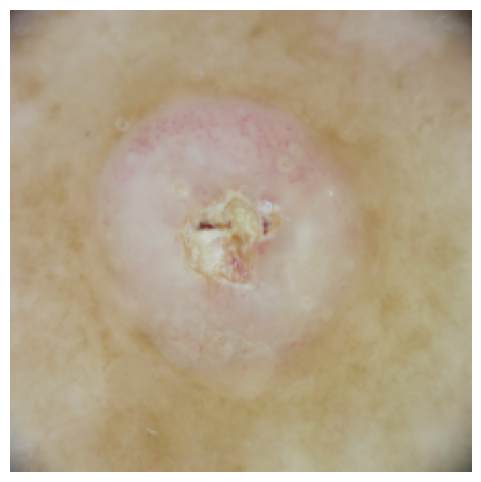

In [101]:
%matplotlib inline
fig_test_img=output_path+'fig_test_img.pdf'
fig=plt.figure(figsize=(6,6))
imgplot=plt.imshow(sample_test_img[img_idx].astype('uint8'))
plt.axis('off')
plt.show()
fig.savefig(fig_test_img, format='pdf', bbox_inches='tight')

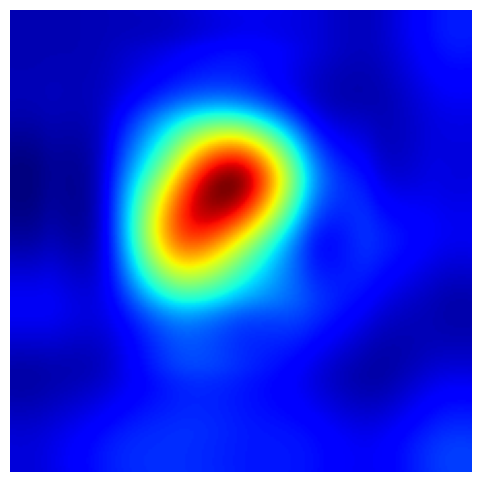

In [102]:
fig_heatmap=output_path+'fig_heatmap.pdf'
fig=plt.figure(figsize=(6,6))
#plt.imshow(sample_test_img[img_idx].astype('uint8'),alpha=1.0)
plt.imshow(cv2.resize(sum_attnmap,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_CUBIC),cmap='jet',alpha=1.0)
plt.axis('off')
plt.show()
fig.savefig(fig_heatmap, format='pdf', bbox_inches='tight')

# Model Plot

In [103]:
tf.keras.utils.plot_model(model, to_file=output_path+'model.pdf', 
    show_shapes=True,    
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=1200,
    layer_range=None,
    show_layer_activations=True,
)

# Move temp to saved_models

In [104]:
from pytz import timezone 
from datetime import datetime
cur_time=datetime.now(timezone("Asia/Kolkata")).strftime('%d-%m-%Y-%H-%M-%S')
name = cur_time + '_' + savedfilename + end 
os.rename(tempfolder, name)
source = '{}'.format(name)+'/'
dest=shutil.move(source, destination)

In [105]:
print(dest)

Results/classification2/2.ISIC2019/Fold1/19-08-2025-22-12-07_epochs_40_test_acc_68.29_ISIC2019_classification_Sel_Aug_Th_0.5
